In [53]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, InputLayer
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.models import load_model

In [54]:
# === STEP 1: Load CSVs (with column headers) ===
X_train_df = pd.read_csv("X_train.csv")
X_val_df = pd.read_csv("X_val.csv")
X_test_df = pd.read_csv("X_test.csv")

In [55]:
# === STEP 2: Combine word columns into full sentences ===
X_train = X_train_df.astype(str).agg(' '.join, axis=1)
X_val = X_val_df.astype(str).agg(' '.join, axis=1)
X_test = X_test_df.astype(str).agg(' '.join, axis=1)

In [32]:
# === Step 3a: Load corresponding labels ===
y_train = pd.read_csv("y_train.csv").squeeze()
y_val = pd.read_csv("y_val.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

In [33]:
# === Step 3b: Ensure matching sample sizes ===
X_train, y_train = X_train.iloc[:len(y_train)], y_train.iloc[:len(X_train)]
X_val, y_val = X_val.iloc[:len(y_val)], y_val.iloc[:len(X_val)]
X_test, y_test = X_test.iloc[:len(y_test)], y_test.iloc[:len(X_test)]

In [34]:
# === Step 4: Automatically detect number of output classes ===
num_classes = len(sorted(y_train.unique()))
print("Number of output classes:", num_classes)

Number of output classes: 3


In [35]:
# === Step 5: TF-IDF Vectorization ===
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=2000, dtype=np.float32)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [36]:
# === Step 6: Build FFN model for TF-IDF input ===
model = Sequential()
model.add(InputLayer(input_shape=(X_train_vec.shape[1],), sparse=True))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [37]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [38]:
# === Step 7: Train model ===
history = model.fit(X_train_vec, y_train,
                    validation_data=(X_val_vec, y_val),
                    epochs=10, batch_size=64)

Epoch 1/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.7805 - loss: 0.5781 - val_accuracy: 0.8325 - val_loss: 0.4716
Epoch 2/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.8402 - loss: 0.4476 - val_accuracy: 0.8401 - val_loss: 0.4538
Epoch 3/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.8578 - loss: 0.3959 - val_accuracy: 0.8399 - val_loss: 0.4541
Epoch 4/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.8736 - loss: 0.3516 - val_accuracy: 0.8392 - val_loss: 0.4638
Epoch 5/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.8906 - loss: 0.3047 - val_accuracy: 0.8378 - val_loss: 0.4822
Epoch 6/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - accuracy: 0.9036 - loss: 0.2687 - val_accuracy: 0.8341 - val_loss: 0.5093
Epoch 7/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - accuracy: 0.9131 - loss: 0.2415 - val_accuracy: 0.8342 - val_loss: 0.5357
Epoch 8/10
4135/4135 ━━━━━━━━━━━━━━━━━━━━ 43s 10ms/step - accuracy: 0.9220 -

In [39]:
# === STEP 8: Save the Trained Model to .h5 ===
model.save("rnn_tfidf_model.h5")
print("✅ Model saved as rnn_tfidf_model.h5")

✅ Model saved as rnn_tfidf_model.h5


In [40]:
# === STEP 9: Reload the Model ===
loaded_model = load_model("rnn_tfidf_model.h5")
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [41]:
# === STEP 10: Recompile the Loaded Model ===
loaded_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [42]:
# === STEP 11: Predict and Evaluate ===
y_pred_probs = loaded_model.predict(X_test_vec)
y_pred = y_pred_probs.argmax(axis=1)

2757/2757 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


In [43]:
# === STEP 12: Evaluation Metrics ===
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))


📊 Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.63      0.67     15314
           1       0.66      0.61      0.63     13406
           2       0.89      0.93      0.91     59491

    accuracy                           0.83     88211
   macro avg       0.75      0.72      0.74     88211
weighted avg       0.82      0.83      0.83     88211



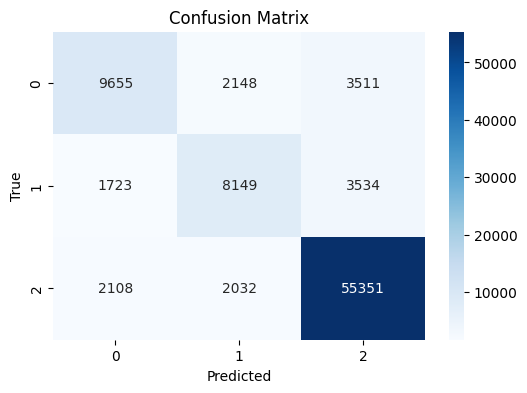

In [45]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [47]:
# AUC Score (Macro)
try:
    auc_score = roc_auc_score(to_categorical(y_test, num_classes=num_classes), y_pred_probs, multi_class='ovo')
    print(f"🧮 AUC Score (macro): {auc_score:.4f}")
except Exception as e:
    print(f"⚠️ AUC Error: {e}")

🧮 AUC Score (macro): 0.8974


In [48]:
# Accuracy
accuracy = (y_pred == y_test).mean()
print(f"✅ Accuracy: {accuracy:.4f}")

✅ Accuracy: 0.8293


### Model Summary: Deep Unidirectional RNN using TF-IDF (Unigram + Bigram)

- **Vectorization**: `TfidfVectorizer(ngram_range=(1, 2), max_features=2000)`
- **Architecture**:
  - Input: Sparse TF-IDF vector (2000 features)
  - Hidden Layers: `Dense(256, relu)` - `Dropout(0.3)` - `Dense(64, relu)`
  - Output Layer: `Dense(3, softmax)`
- **Validation Accuracy**: **83.42%**
- **Test Accuracy**: **82.93%**

#### F1 Scores:
- **Negative Class**: 0.67
- **Neutral Class**: 0.63
- **Positive Class**: 0.91

- **Macro F1 Score**: `0.74`
- **Macro AUC Score**: `0.8974`

---

### Tuning Round 1: Increased Epochs up to 10 (Baseline Run)

- **Validation Accuracy Trend**:
  - Epoch 1: `83.25%`
  - Epoch 2: **`84.01%`**
  - Epoch 10: `82.89%`
- **Observation**: Signs of overfitting after Epoch 3 as validation loss increased.
- **Conclusion**: Early stopping around epoch 2 - 3 may yield better generalization.

---

### What Could Be Done:

- ✅ Add a **Bidirectional RNN** (e.g., `Bidirectional(LSTM)`) to capture both directions of context.
- ✅ Replace TF-IDF with **Word2Vec** or **FastText** embeddings to incorporate semantic similarity.
- ✅ Increase `Dropout` to 0.5 to reduce overfitting.
- ✅ Use **class weights** or **focal loss** to handle imbalance and improve Class 1 performance.
